DATASET IRIS:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


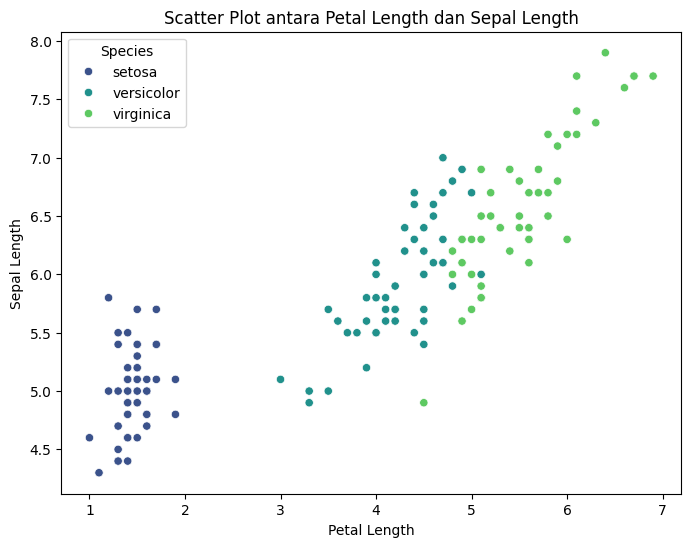

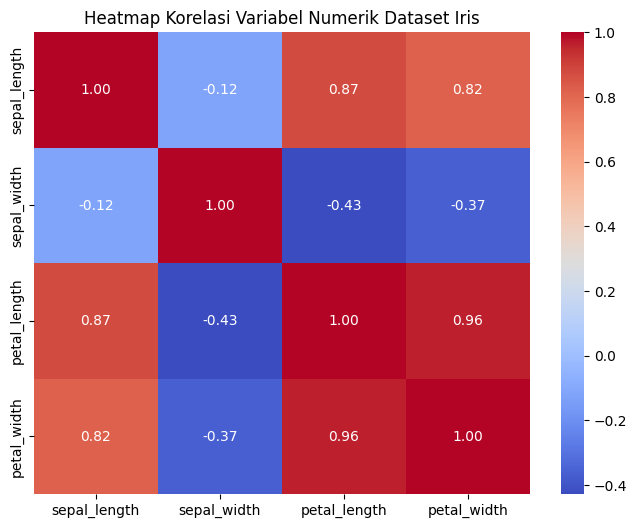

In [2]:
# --- NOMOR 1: Visualisasi dengan Matplotlib & Seaborn ---
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Load dataset Iris
iris = sns.load_dataset("iris")

# Tampilkan 5 data pertama
print("DATASET IRIS:")
print(iris.head())

# --- Scatter Plot antara petal_length dan sepal_length ---
plt.figure(figsize=(8,6))
sns.scatterplot(data=iris, x='petal_length', y='sepal_length', hue='species', palette='viridis')
plt.title('Scatter Plot antara Petal Length dan Sepal Length')
plt.xlabel('Petal Length')
plt.ylabel('Sepal Length')
plt.legend(title='Species')
plt.show()

# --- Heatmap untuk variabel numerik ---
plt.figure(figsize=(8,6))
sns.heatmap(iris.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Variabel Numerik Dataset Iris')
plt.show()


In [3]:
# --- NOMOR 2: Analisis Deskriptif & Uji ANOVA ---

# Hitung mean, median, modus untuk setiap variabel numerik
stats_table = pd.DataFrame(columns=['Mean', 'Median', 'Modus'])

for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    mean_val = iris[col].mean()
    median_val = iris[col].median()
    mode_val = iris[col].mode()[0]
    stats_table.loc[col] = [round(mean_val, 2), round(median_val, 2), round(mode_val, 2)]

print("\n=== Statistik Deskriptif Dataset Iris ===")
print(stats_table)

# --- Uji ANOVA ---
anova_results = pd.DataFrame(columns=['F-Statistic', 'p-Value', 'Kesimpulan'])

for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    group1 = iris[iris['species'] == 'setosa'][col]
    group2 = iris[iris['species'] == 'versicolor'][col]
    group3 = iris[iris['species'] == 'virginica'][col]
    
    f_stat, p_val = stats.f_oneway(group1, group2, group3)
    
    kesimpulan = "Ada perbedaan signifikan" if p_val < 0.05 else "Tidak signifikan"
    anova_results.loc[col] = [round(f_stat, 3), round(p_val, 5), kesimpulan]

print("\n=== Hasil Uji ANOVA Tiap Variabel ===")
print(anova_results)


=== Statistik Deskriptif Dataset Iris ===
              Mean  Median  Modus
sepal_length  5.84    5.80    5.0
sepal_width   3.06    3.00    3.0
petal_length  3.76    4.35    1.4
petal_width   1.20    1.30    0.2

=== Hasil Uji ANOVA Tiap Variabel ===
              F-Statistic  p-Value                Kesimpulan
sepal_length      119.265      0.0  Ada perbedaan signifikan
sepal_width        49.160      0.0  Ada perbedaan signifikan
petal_length     1180.161      0.0  Ada perbedaan signifikan
petal_width       960.007      0.0  Ada perbedaan signifikan
